In [ ]:
# Install needed libs. You can safely ignore "dependency resolver" warnings.
!pip install -Uq llm 'urllib3>2' fastkaggle

## Intro and setup

The [LLM Science Exam](https://www.kaggle.com/competitions/kaggle-llm-science-exam) competition tasks you with solving challenging multiple choice science questions, such as choosing the option which 'accurately describes the impact of Modified Newtonian Dynamics (MOND) on the observed "missing baryonic mass" discrepancy in galaxy clusters'. A couple of years ago these capabilities were beyond the capabilities of machine learning, but today we can train our own model to solve this problem!

But before we start training models, we need to learn some basics of large language models (LLMs). If we're not good at using LLMs ourselves, we're not likely to be much good at writing code to train and use LLMs either! So today we'll see how to use OpenAI's pretrained models to answer the questions, and (more importantly!) to more deeply understand the data.

First, we'll import some useful libraries:

In [ ]:
import time, pandas as pd, numpy as np
from fastcore.utils import *
from fastkaggle import *

fastcore's `Path.ls()` method is useful for quickly looking at what's in a directory. Here's the files for the competition:

In [ ]:
Path.BASE_PATH = path = setup_comp('kaggle-llm-science-exam')
path.ls()

Let's take a look at our training set:

In [ ]:
trn = pd.read_csv(path/'train.csv')
trn

## Using the OpenAI API

Normally in Kaggle competitions, we would do "EDA" (exploratory data analysis) at this point, looking at stuff like histograms of our data. But this is a natural language competition, so I think it's more useful to do natural language exploration.

The easiest way currently to get high-quality natural language responses is to use OpenAI's API. We'll need to be able to pass our questions as prompts, so we'll define a function to stringify the records:

In [ ]:
def prompt1(r):
    return f"""Question: {r.prompt}
A: {r.A}
B: {r.B}
C: {r.C}
D: {r.D}
E: {r.E}
Answer: """

Let's take a look at an example:

In [ ]:
r0 = trn.loc[0]
print(prompt1(r0), r0.answer)

We can now create a connection to OpenAI's GPT-3.5 Turbo model, which provides fairly good results and costs very little (around \$2.50 per million words at the time of writing). We will use the `llm` library, which provides a conveniet and simple interface to accessing LLMs:

In [ ]:
import os,llm
model = llm.get_model("gpt-3.5-turbo")

You'll need to sign up for OpenAI's APIs, which you can do [here](https://openai.com/blog/openai-api). They'll give you an API key, which you now need to paste into a Kaggle secret. Click "Add-ons" in this notebook, then "Secrets", add a secret called "openai", and paste in your key.

In [ ]:
if iskaggle:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    os.environ['OPENAI_API_KEY'] = secrets.get_secret("openai")

model.key = os.environ['OPENAI_API_KEY']

Let's test it on the first science question:

In [ ]:
response = model.prompt(prompt1(r0))
response.text()

When I ran it, I got the right answer, D (although OpenAI doesn't always give the same answer, so you might see something different).

## Are there any wrong answers?

Let's see if there are any wrong answers to the first 10 questions. We'll create a little function we can use to print out a prompt and answer, and a function that checks whether the model's answer is correct.

In [ ]:
def summ(i):
    r = trn.loc[i]
    print(i, prompt1(r), r.answer)

def check1(r):
    ans = model.prompt(prompt1(r)).text()
    if ans[0]==r.answer: return
    return ans,r.answer

We now run `check1` up to 10 times, printing the first wrong answer we find (if any):

In [ ]:
for i in range(10):
    resp = check1(trn.loc[i])
    if resp:
        summ(i)
        print(resp)
        break

When I ran this, GPT 3.5 got the wrong answer for "*Which of the following statements accurately describes the origin and significance of the triskeles symbol?*" Curiously, that's not even a science question -- it's a question about iconography of the European Neolithic and Bronze Age. I have no idea if the Kaggle response is right or wrong! Let's try to find out...

## Diving deeper using Bing

We can get more detailed and up to date information by using Bing's "creative mode", which generally uses GPT 4, and also accesses the internet as needed. There isn't an official API to this, so I just manually pasted information to the web page.

First, we can give the model a chance to "think about" the answer by asking the question without multiple choice options. If we pass in only the request "*Please accurately describe the origin and significance of the triskeles symbol.*", we get back 5 paragraphs of information, including this:

> The triskeles symbol is an ancient motif that consists of three spirals or three legs radiating from a common center. It has been used by various cultures and civilizations throughout history, but it is especially associated with the Celtic and Greek traditions. The origin and significance of the triskeles symbol may vary depending on the context and interpretation, but here are some possible meanings:
> 
> - The triskeles symbol may represent the sun, the source of life and energy. The three spirals could symbolize the movement and cycles of the sun, such as the solstices and equinoxes. The sun was an important element in many ancient religions and mythologies, and the triskeles symbol may have been a way of expressing reverence and gratitude for its power and influence

If we then immediately follow up with the multiple choice question, the above details will be fed back to the model for us automatically, so it can use this "thinking" to help it answer the question. Instead of the repeating the question, I followed up with "*First go through each of the 5 options, explaining why it is or isn't a good description, and then finally say which you think is most accurate.*", and pasted in the 5 choices from above. This two-step approach is a good way to get better results from your prompts.

Bing gave a 6 paragraph answer, plus references, including:

> A: This option is partially accurate, but it contains some errors and omissions. The triskeles symbol of three human legs was indeed adopted as an emblem by the rulers of Syracuse, a Greek city-state in Sicily, in the 4th century BCE. However, there is no evidence that they reconstructed it as a feminine divine triad, as the symbol was already in use by other cultures before them. The Greek name of Sicily, Trinacria, does mean “having three headlands”, but it is not clear if this name influenced the choice of the symbol or vice versa. The head of Medusa at the center of the Sicilian triskeles does not represent the three headlands, but rather the protection and power of the Gorgon, a mythical creature whose gaze could turn anyone to stone. Medusa was also associated with the goddess Athena, who wore her head on her shield
> 
> B: This option is mostly accurate, but it could be more specific and detailed. The triskeles symbol of three interlinked spirals was indeed adopted as an emblem by the rulers of Syracuse, and it has been used in modern flags of Sicily since 1943. The ancient Greek name for Sicily, Trinacria, does mean “Sicily with three corners”, and it may have some connection to the symbol, but this is not certain. The head of Medusa at the center is a representation of the island’s rich cultural heritage, but it also has a deeper meaning as a symbol of protection and power, as well as a link to the goddess Athena
>
> ...
>
> Based on my evaluations, I think that option B is the most accurate description among the five options you have given. It provides some correct information about the origin and significance of the triskeles symbol without making any major errors or omissions.

So Bing thinks the Kaggle answer is wrong. But we know that the questions were created from Wikipedia pages, so perhaps the Wikipedia page is wrong. We can have Bing use a web page as context for answering questions, by opening a page in Edge and using the Bing sidebar (you must first enable page context in Edge settings). This is one of the most under-appreciated LLM resources. It even works with PDFs!

To enable it, in Microsoft Edge go to settings, then type "sidebar" in the settings search, scroll down to "app specific settings", and click "Discover":

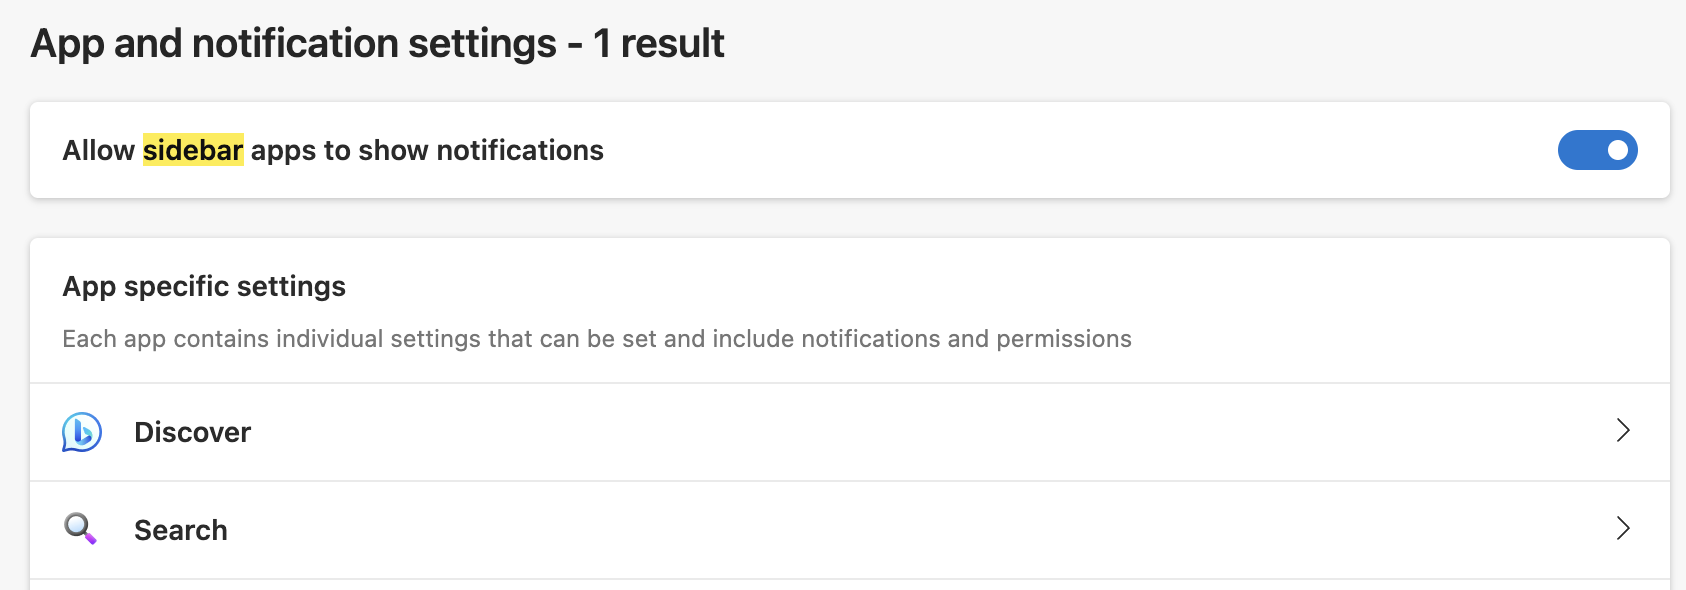

From here, enable web-page access:
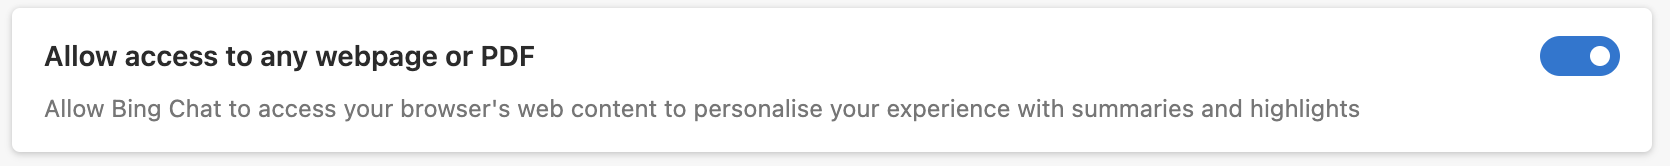

We can now open the Triskelion wikipedge page and repeat the multiple choice question, but this time we use the sidebar, and prepend our question with "Based on this page, ". This causes Bing to use the full wikipedia page as context in answering the question.

It provides a long answer, explaining the pros and cons of each option, and concludes:

> Based on the information on this page, the best answer to your question is B. The triskeles symbol is a representation of three interlinked spirals, which was adopted as an emblem by the rulers of Syracuse1. Its usage in modern flags of Sicily has its origins in the ancient Greek name for the island, Trinacria, which means "Sicily with three corners."

I asked then "*Why is (A) not a good answer?*" and Bing's reply included:

> ...while it is true that Honoré Théodoric d’Albert de Luynes reconstructed a feminine divine triad based on his study of the triskeles symbol and other symbols found in ancient art, this interpretation is not supported by the evidence on this page.

I checked the Wikipedia page text, which includes this information:

> The Duc de Luynes in his 1835 study noted the co-occurrence of the symbol with the eagle, the cockerel, the head of Medusa, Perseus, three crescent moons, three ears of corn, and three grains of corn. From this, he reconstructed feminine divine triad which he identified with the "triple goddess" Hecate.

This is indeed the only mention of the "feminine divine" in the Wikipedia page. Therefore it does appear that the answer in the Kaggle dataset is incorrect. It treats an old interpretation from 1835 as being the correct answer, rather than understanding that the wikipedia page is simply describing historical guesses here.

Using online LLMs in this way is an important skill for data scientists. Other tools we're used to, like Google and Stackoverflow, are still useful of course -- but we should also be open to adding new tools to our toolbox! In this case, Bing has helped us to quickly understand an issue in our data.

## GPT-3.5 baseline accuracy

It's very useful to have a baseline to compare to, particularly in order to have something to compare our own model's results to. Let's see how good a basic GPT-3.5 baseline is.

It will be faster if we query OpenAI multiple times in parallel. The easiest way to do that is to use Python's `ThreadPoolExecutor`.

In [ ]:
from concurrent.futures import ThreadPoolExecutor

We'll call our `check1` function using 25 parallel threads. `ThreadPoolExecutor.map` returns a generator containing all the results in order, which we'll turn into a list for further analysis:

In [ ]:
def f(o): return check1(trn.loc[o])
with ThreadPoolExecutor(25) as e: resps = e.map(f, list(range(200)))

In [ ]:
resps = list(resps)

`check1` returns `None` for correct answers, so let's see what % of the time GPT-3.5 Turbo is getting the "wrong" (i.e. different to Kaggle's dataset) answer:

In [ ]:
np.mean([o is not None for o in resps])

In my testing I'm seeing around 30% wrong answers.

Perhaps some of the answers aren't returning a correct A-E option at all? Let's test:

In [ ]:
[o for o in resps if o is not None and o[0][0] not in 'ABCDE']

I found one answer that returned "The correct answer is A: ..." instead of just "A: ..."

## Better prompting and conversations

In order to get better answers, we need to use better prompts. To do this, we need to understand a bit about how LLMs work under the hood.

Nearly all current LLMs, including GPT 3.5 Turbo, are *autoregressive*. That means that they generate the first token of the response, then the second, then the third, and so forth in order. (We won't worry about the details of the meaning of "token" for now -- most of the time a "token" is simply a word.)

Each time is generates one token, it's doing lots of calculations. The more tokens it's produced, the more calculations it's down. But by asking the model to produce the answer A-E *first*, we're not giving it any "thinking time" at all! Let's see if we can prompt it to first do some thinking, and then produce a response. One simple way to do this is to "chat" to it -- in a "chat", the entire session of questions and answers so far is fed back to the model each time.

Here's an example -- we'll first create a `conversation`:

In [ ]:
conv = model.conversation()

Now we can pass a prompt to that conversation:

In [ ]:
conv.prompt("Hello I'm Jeremy.").text()

If we continue to use `conv.prompt`, it will "remember" the previous conversation. The way this works behind the scenes is that the entire history is passed back to OpenAI each time:

In [ ]:
conv.prompt("Do you remember my name?").text()

To see whether this approach works well, we need to find a question which seems to be correct in the Kaggle dataset, but incorrect in our answers (since then we can see if the new approach fixes it). It took me quite a while to find one -- the first 10 or so I checked were either wrong in the Kaggle dataset, or there were multiple equally-valid answers. Eventually I found that the previous prompt incorrectly answered "B" to the following question:

In [ ]:
summ(52)

It's a subtle point, but *resistivity* is an intrinsic property of a material, meaning it's independent of the material's shape and size. It's *resistance* that depends on these physical attributes. That's why (C) is better than (B), and the Kaggle answer is therefore correct.

Let's try having a conversation about this -- first we'll ask for answer without providing the multiple choice options:

In [ ]:
conv = model.conversation()
q = "Precisely and fully describe the answer to the following question: what is resistivity?"
print(conv.prompt(q).text())

Next we follow up by asking to order the five options in order of accuracy:

In [ ]:
def prompt2(r):
    return f"""I will ask a multiple choice question, with 5 answers A-E.
First, output 'Options: ' followed by going through each of the 5 options, explaining why it is or isn't a good description.
Then, output 'Summary: ' followed by a description of which you think is most accurate, and why.
Finally, output 'Answers: ' followed by the 5 answers A-E sorted from best answer to worst. E.g 'Answers: B C E A D'.
Reminder: it's VERY IMPORTANT the final line of your response is text text 'Answers: ' followed by the sorted list of answers A-E.

Question: {r.prompt}
A: {r.A}
B: {r.B}
C: {r.C}
D: {r.D}
E: {r.E}
"""

In [ ]:
q = prompt2(trn.loc[52])
print(conv.prompt(q).text())

We can even ask followup questions -- we see that it's getting the right answer for the right reason:

In [ ]:
q = "Why is (C) better than (B)?"
print(conv.prompt(q).text())

In order to score this conversational approach, we'll once again call the API in parallel. First we need a function that will complete the conversation and return the result text:

In [ ]:
def resp2(r):
    conv = model.conversation()
    q = f"Precisely and fully describe the answer to the following question: {r.prompt}"
    ans1 = conv.prompt(q).text()
    return conv.prompt(prompt2(r)).text()

Let's check it:

In [ ]:
print(resp2(trn.loc[52]))

Since it seems to be working nicely, we'll run it on all the rows. This will cost a bit more than the previous approach, since there's quite a long response and we're calling OpenAPI twice. I like to do a quick price check to make sure it won't send me broke. In this case, it looks like it might be around 1000 words per conversation, and we've got 200 to do, at around $2/million words, so that gives us:

In [ ]:
200*1000*2 / 1_000_000

Only $0.40 by the looks of it, so let's go ahead:

In [ ]:
def f(o):
    try: return resp2(trn.loc[o])
    except Exception as e: return str(e)
with ThreadPoolExecutor(50) as e: resps = e.map(f, list(range(200)))

In [ ]:
resps = list(resps)

I've made a CSV of `resps` available as a dataset, which you can grab from [here](https://www.kaggle.com/datasets/jhoward/llm-science-gpt35). That way to can save a bit of time and money by avoiding re-running the calls to OpanAI. To create it, I used these 2 lines of code:

```python
df = pd.DataFrame(resps, columns=["response"])
df.to_csv('response.csv', index=False)
```

To use the dataset, use this code:

```python
df = pd.read_csv('response.csv')
resps = list(df.response)
```

After looking over the responses (always look at your data!) I noticed that sometimes the model had responded with just one answer, and in one case hadn't answered at all. This function simply repeats the single answer five times if there's only one, or responds 'ABCDE' if there's no answer.

In [ ]:
def get_ans(o):
    m = re.search(r'Answers:\s*([A-E])\s+([A-E])\s+([A-E])\s+([A-E])\s+([A-E])', o)
    if m: return m.groups()
    m = re.search(r'Answers:\s*([A-E])', o)
    return (m[1],m[1],m[1],m[1],m[1]) if m else 'ABCDE'

anss = [get_ans(o) for o in resps]

## Scoring our answers

Now that we have a set of answers to every question, we can calculate the score we'd expect to see on the Kaggle leaderboard if we used this approach. The Kaggle evaluation metric gives you a full point if you get the right answer with your first guess, 2/3 if it's your second guess, and 1/3 if it's your third guess.

In [ ]:
def score(act,pred):
    return 1 if act==pred[0] else 2/3 if act==pred[1] else 1/3 if act==pred[2] else 0

In [ ]:
np.mean([score(a,b) for a,b in zip(trn.answer, anss)])

At the time of writing, this would get us to 4th place on the leaderboard in the competition. Of course, we can't *actually* get this place right now, because we're not able to call internet APIs in our actual submissions. But it does suggest that we may be able to get pretty good results by just using an off-the-shelf open source LLM, since the best current open source models have similar levels of capability to GPT 3.5.

Perhaps the most useful thing to do with these responses are to look at those cases where GPT 3.5 didn't get the right answer in any of the top 3 answers. See if you can figure out why -- use a similar approach to what I showed above, using Bing and the wikipedia page. That might give you some better understanding of how the Kaggle team created the dataset, so that you can better come up with answer that match the data and approach they used.

If you enjoyed this notebook, please upvote it to help others find it, and to encourage me to write more. If you upvote it, be careful you don't accidentally upvote your copy that's created when you click "Copy & Edit" -- you can find my original at [this link](https://www.kaggle.com/code/jhoward/getting-started-with-llms). (If you create a fork of this notebook, please include credit and a link to this original at the top of your version.)

In [ ]:
# Push notebook to Kaggle if running locally
if not iskaggle:
    push_notebook('jhoward', 'getting-started-with-llms', title='Getting Started With LLMs',
                  file='getting-started-with-llms.ipynb', competition='kaggle-llm-science-exam',
                  private=False, gpu=False)